# Результат 3. Кластеризация и прогнозирование продаж

В этом ноутбуке реализовано:
- Клиентская сегментация (RFM-кластеризация, K-Means)
- Прогнозирование продаж
- Экспорт артефактов для BI-дашборда

In [2]:
import os
import warnings
from pathlib import Path

os.environ["LOKY_MAX_CPU_COUNT"] = "4"
tmp_root = Path("tmp")
tmp_root.mkdir(exist_ok=True)
(tmp_root / "mpl_cache").mkdir(exist_ok=True)
(tmp_root / "xdg_cache").mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str((tmp_root / "mpl_cache").resolve())
os.environ["XDG_CACHE_HOME"] = str((tmp_root / "xdg_cache").resolve())

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from IPython.display import Markdown, display
from matplotlib.gridspec import GridSpec
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11

DATA_PATH = Path("data/sample_superstore.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Вспомогательные функции
def money(v: float) -> str:
    return f"${v:,.2f}"

def percent(v: float) -> str:
    return f"{v:.1%}"

def display_md(text: str) -> None:
    display(Markdown(text))

def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() else np.nan

def wape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom * 100 if denom else np.nan

def regression_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
        "WAPE": wape(y_true, y_pred),
        "R²": r2_score(y_true, y_pred),
    }


def load_transaction_data(path: Path) -> pd.DataFrame:
    data = pd.read_csv(path, encoding="latin-1")
    data["Order Date"] = pd.to_datetime(data["Order Date"], format="%m/%d/%Y")
    data["Ship Date"] = pd.to_datetime(data["Ship Date"], format="%m/%d/%Y")
    data["Postal Code"] = data["Postal Code"].astype("Int64").astype(str)
    data["Delivery Days"] = (data["Ship Date"] - data["Order Date"]).dt.days
    data["Order Year"] = data["Order Date"].dt.year
    data["Order Quarter"] = data["Order Date"].dt.quarter
    data["Order Month"] = data["Order Date"].dt.month
    data["Order Month Start"] = data["Order Date"].dt.to_period("M").dt.to_timestamp()
    data["Order Month Name"] = pd.Categorical(
        data["Order Date"].dt.strftime("%b"),
        categories=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
        ordered=True,
    )
    data["Is Loss"] = (data["Profit"] < 0).astype(int)
    data["Profit Margin"] = np.where(data["Sales"] > 0, data["Profit"] / data["Sales"], 0.0)
    data["Discount Band"] = pd.Categorical(
        pd.cut(data["Discount"], bins=[-0.001, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
               labels=["0%", "0-10%", "10-20%", "20-30%", "30-50%", "50%+"]),
        ordered=True,
    )
    return data


def prepare_customer_table(data: pd.DataFrame) -> pd.DataFrame:
    reference_date = data["Order Date"].max() + pd.Timedelta(days=1)
    rfm = data.groupby("Customer ID").agg(
        Recency=("Order Date", lambda x: (reference_date - x.max()).days),
        Frequency=("Order ID", "nunique"),
        Monetary=("Sales", "sum"),
    )
    customer_extra = data.groupby("Customer ID").agg(
        Total_Profit=("Profit", "sum"),
        Avg_Profit_Margin=("Profit Margin", "mean"),
        Avg_Discount=("Discount", "mean"),
        Pct_Discounted=("Discount", lambda x: (x > 0).mean()),
        N_Categories=("Category", "nunique"),
        N_SubCategories=("Sub-Category", "nunique"),
        Avg_Order_Value=("Sales", "mean"),
        Lifetime_Days=("Order Date", lambda x: (x.max() - x.min()).days),
        Loss_Rate=("Is Loss", "mean"),
    )
    customer_segment = data.groupby("Customer ID")["Segment"].agg(
        lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]
    )
    customers = rfm.join(customer_extra).join(customer_segment.rename("Segment"))
    customers["Monetary_log"] = np.log1p(customers["Monetary"])
    return customers


def cluster_method_summary(X_scaled, labels):
    unique = set(labels)
    n = len(unique) - (1 if -1 in unique else 0)
    noise = float(np.mean(labels == -1)) if -1 in unique else 0.0
    if n < 2:
        return {"Clusters": n, "NoiseShare": noise, "Silhouette": np.nan,
                "Calinski_Harabasz": np.nan, "Davies_Bouldin": np.nan}
    mask = labels != -1
    return {
        "Clusters": n, "NoiseShare": noise,
        "Silhouette": silhouette_score(X_scaled[mask], labels[mask]),
        "Calinski_Harabasz": calinski_harabasz_score(X_scaled[mask], labels[mask]),
        "Davies_Bouldin": davies_bouldin_score(X_scaled[mask], labels[mask]),
    }


def build_monthly_panel(data: pd.DataFrame) -> pd.DataFrame:
    sc_to_cat = data[["Sub-Category", "Category"]].drop_duplicates().set_index("Sub-Category")["Category"]
    group_cols = ["Sub-Category", "Region"]
    monthly = data.groupby(group_cols + ["Order Month Start"]).agg(
        Sales=("Sales", "sum"), Profit=("Profit", "sum"), Quantity=("Quantity", "sum"),
        N_Orders=("Order ID", "nunique"), N_Customers=("Customer ID", "nunique"),
        Avg_Discount=("Discount", "mean"),
    ).reset_index().rename(columns={"Order Month Start": "Month"})

    full_index = pd.MultiIndex.from_product(
        [sorted(monthly["Sub-Category"].unique()), sorted(monthly["Region"].unique()),
         pd.date_range(monthly["Month"].min(), monthly["Month"].max(), freq="MS")],
        names=["Sub-Category", "Region", "Month"],
    )
    monthly = monthly.set_index(group_cols + ["Month"]).reindex(full_index, fill_value=0).reset_index()
    monthly["Category"] = monthly["Sub-Category"].map(sc_to_cat)
    return monthly.sort_values(group_cols + ["Month"]).reset_index(drop=True)


def add_sales_features(group: pd.DataFrame) -> pd.DataFrame:
    g = group.sort_values("Month").copy()
    for lag in [1, 2, 3, 4, 6, 9, 12]:
        g[f"Sales_lag_{lag}m"] = g["Sales"].shift(lag)
    g["Sales_roll_mean_3m"] = g["Sales"].shift(1).rolling(3, min_periods=1).mean()
    g["Sales_roll_mean_6m"] = g["Sales"].shift(1).rolling(6, min_periods=1).mean()
    g["Sales_roll_mean_12m"] = g["Sales"].shift(1).rolling(12, min_periods=1).mean()
    g["Sales_roll_std_3m"] = g["Sales"].shift(1).rolling(3, min_periods=2).std()
    g["Sales_growth_1m"] = g["Sales"].pct_change(1).shift(1)
    g["Avg_Discount_lag_1m"] = g["Avg_Discount"].shift(1)
    g["N_Orders_lag_1m"] = g["N_Orders"].shift(1)
    g["N_Customers_lag_1m"] = g["N_Customers"].shift(1)
    return g


def prepare_forecasting_frame(monthly_base: pd.DataFrame):
    frames = []
    for _, grp in monthly_base.groupby(["Sub-Category", "Region"]):
        frames.append(add_sales_features(grp))
    panel = pd.concat(frames, ignore_index=True)

    panel["Month_num"] = panel["Month"].dt.month
    panel["Quarter"] = panel["Month"].dt.quarter
    panel["Year"] = panel["Month"].dt.year
    panel["Month_sin"] = np.sin(2 * np.pi * panel["Month_num"] / 12)
    panel["Month_cos"] = np.cos(2 * np.pi * panel["Month_num"] / 12)
    panel["Is_Q4"] = (panel["Quarter"] == 4).astype(int)

    dummies = pd.get_dummies(panel[["Sub-Category", "Region"]], prefix=["SC", "Reg"], dtype=int)
    panel = pd.concat([panel, dummies], axis=1)

    exclude = {"Sub-Category", "Region", "Category", "Month", "Sales", "Profit",
               "Quantity", "N_Orders", "N_Customers", "Avg_Discount"}
    feature_cols = [c for c in panel.columns if c not in exclude]

    # Clean inf/nan in derived columns
    for c in feature_cols:
        panel[c] = panel[c].replace([np.inf, -np.inf], np.nan)

    lag_cols = [c for c in feature_cols if "Sales_lag_" in c]
    model_frame = panel.dropna(subset=lag_cols).copy()
    model_frame[feature_cols] = model_frame[feature_cols].fillna(0)

    return panel, model_frame, feature_cols


def build_recursive_forecast(history_base, models_by_category, feature_cols, future_months,
                              n_bootstrap=0, all_bootstrap_models=None):
    """Recursive multi-step forecast with optional bootstrap CI."""
    current = history_base[["Sub-Category", "Region", "Category", "Month",
                            "Sales", "Avg_Discount"]].copy()
    current = current.sort_values(["Sub-Category", "Region", "Month"]).reset_index(drop=True)

    subcategories = sorted(current["Sub-Category"].unique())
    regions = sorted(current["Region"].unique())
    sc_dummy_cols = [c for c in feature_cols if c.startswith("SC_")]
    reg_dummy_cols = [c for c in feature_cols if c.startswith("Reg_")]
    sc_to_cat = current.drop_duplicates("Sub-Category").set_index("Sub-Category")["Category"]

    forecast_rows = []

    for step, month in enumerate(future_months):
        month_rows = []
        for sc in subcategories:
            category = sc_to_cat[sc]
            for reg in regions:
                hist = current[(current["Sub-Category"] == sc) &
                               (current["Region"] == reg)].sort_values("Month")
                sales_h = hist["Sales"].tolist()
                disc_h = hist["Avg_Discount"].tolist()

                def safe_lag(vals, lag):
                    return float(vals[-lag]) if len(vals) >= lag else 0.0

                row = {
                    "Month_num": month.month, "Quarter": month.quarter,
                    "Year": month.year,
                    "Month_sin": np.sin(2 * np.pi * month.month / 12),
                    "Month_cos": np.cos(2 * np.pi * month.month / 12),
                    "Is_Q4": int(month.quarter == 4),
                    "Avg_Discount_lag_1m": safe_lag(disc_h, 1),
                    "Sales_roll_mean_3m": float(np.mean(sales_h[-3:])) if sales_h else 0.0,
                    "Sales_roll_mean_6m": float(np.mean(sales_h[-6:])) if sales_h else 0.0,
                    "Sales_roll_mean_12m": float(np.mean(sales_h[-12:])) if sales_h else 0.0,
                    "Sales_roll_std_3m": float(np.std(sales_h[-3:], ddof=1))
                        if len(sales_h) >= 3 else 0.0,
                    "Sales_growth_1m": (sales_h[-1] - sales_h[-2]) / sales_h[-2]
                        if len(sales_h) >= 2 and sales_h[-2] != 0 else 0.0,
                    "N_Orders_lag_1m": 0.0, "N_Customers_lag_1m": 0.0,
                }
                for lag in [1, 2, 3, 4, 6, 9, 12]:
                    row[f"Sales_lag_{lag}m"] = safe_lag(sales_h, lag)
                for dc in sc_dummy_cols + reg_dummy_cols:
                    row[dc] = 0
                row[f"SC_{sc}"] = 1
                row[f"Reg_{reg}"] = 1

                X_new = pd.DataFrame([row])[feature_cols].fillna(0)
                model = models_by_category.get(category)
                predicted = max(float(model.predict(X_new)[0]), 0.0)

                # Bootstrap predictions
                boot_preds = []
                if n_bootstrap > 0 and all_bootstrap_models is not None:
                    for bm_dict in all_bootstrap_models:
                        bm = bm_dict.get(category)
                        boot_preds.append(max(float(bm.predict(X_new)[0]), 0.0))

                base_row = {"Sub-Category": sc, "Region": reg, "Category": category,
                            "Month": month, "Sales": predicted,
                            "Avg_Discount": float(np.mean(disc_h[-3:])) if disc_h else 0.0}

                forecast_entry = {
                    "Sub-Category": sc, "Region": reg, "Category": category,
                    "Month": month, "Predicted_Sales": predicted,
                    "Forecast_Step": step + 1,
                }
                if boot_preds:
                    forecast_entry["Lower_10"] = float(np.percentile(boot_preds, 10))
                    forecast_entry["Upper_90"] = float(np.percentile(boot_preds, 90))

                month_rows.append(forecast_entry)
                current = pd.concat([current, pd.DataFrame([base_row])], ignore_index=True)

        forecast_rows.extend(month_rows)

    return pd.DataFrame(forecast_rows)


In [3]:
df = load_transaction_data(DATA_PATH)
display(df.head(3))
display_md(f"**Размер датасета:** {df.shape[0]:,} строк × {df.shape[1]} столбцов")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Delivery Days,Order Year,Order Quarter,Order Month,Order Month Start,Order Month Name,Is Loss,Profit Margin,Discount Band
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.000,41.914,3,2016,4,11,2016-11-01,Nov,0,0.160,0%
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,3,0.000,219.582,3,2016,4,11,2016-11-01,Nov,0,0.300,0%
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.000,6.871,4,2016,2,6,2016-06-01,Jun,0,0.470,0%


**Размер датасета:** 9,994 строк × 30 столбцов

## 1. Кластеризация клиентов

Будем использовать RFM-подход, но с расширенными признаками. Сначала сравниваем два набора фичей (чистый RFM vs расширенный),
затем выбираем оптимальное k и строим интерпретируемые профили.

,Recency,Frequency,Monetary,Total_Profit,Avg_Profit_Margin,Avg_Discount,Pct_Discounted,N_Categories,N_SubCategories,Avg_Order_Value,Lifetime_Days,Loss_Rate,Segment,Monetary_log
Customer ID,,,,,,,,,,,,,,
AA-10315,185,5,"5,563.560",-362.882,0.265,0.091,0.455,3,9,505.778,1186,0.091,Consumer,8.624
AA-10375,20,9,"1,056.390",277.382,0.319,0.080,0.400,3,7,70.426,1330,0.000,Consumer,6.964
AA-10480,260,4,"1,790.512",435.827,0.331,0.017,0.083,3,7,149.209,1077,0.000,Consumer,7.491
AA-10645,56,6,"5,086.935",857.803,0.244,0.064,0.222,3,9,282.607,1232,0.111,Consumer,8.535
AB-10015,416,3,886.156,129.346,0.105,0.067,0.333,3,5,147.693,996,0.167,Consumer,6.788


,count,mean,std,min,25%,50%,75%,max
Recency,793.000,147.800,186.210,1.000,31.000,76.000,184.000,"1,166.000"
Frequency,793.000,6.320,2.550,1.000,5.000,6.000,8.000,17.000
Monetary,793.000,"2,896.850","2,628.670",4.830,"1,146.050","2,256.390","3,785.280","25,043.050"
Total_Profit,793.000,361.160,894.260,"-6,626.390",36.610,227.830,560.010,"8,981.320"
Avg_Discount,793.000,0.160,0.090,0.000,0.090,0.150,0.210,0.700


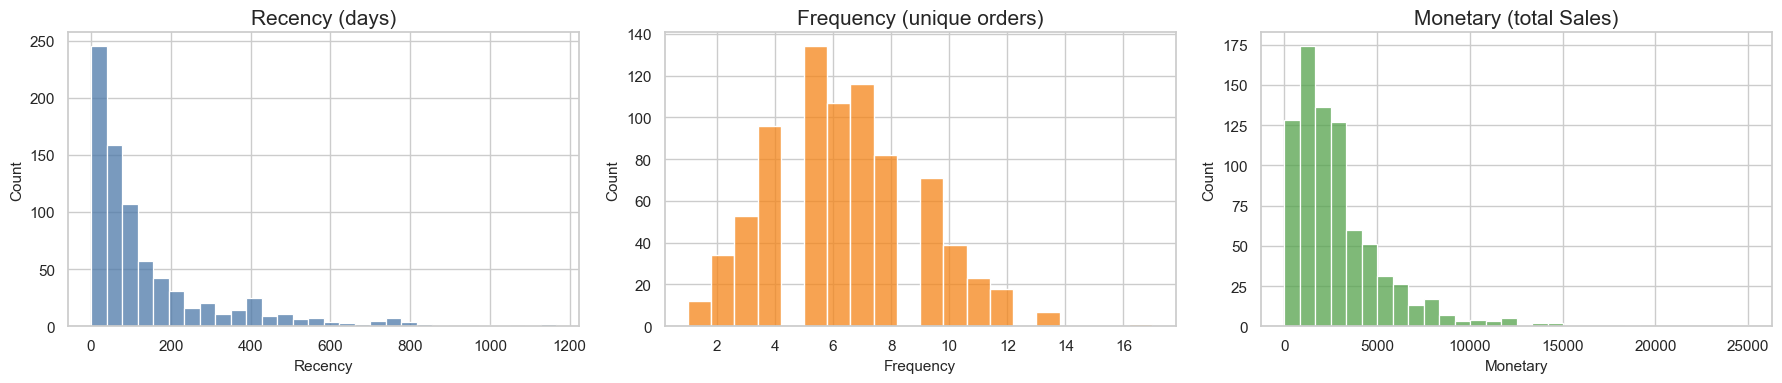

In [4]:
customers = prepare_customer_table(df)

display(customers.head())
display(customers[["Recency", "Frequency", "Monetary", "Total_Profit", "Avg_Discount"]].describe().T.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(customers["Recency"], bins=30, ax=axes[0], color="#4C78A8")
axes[0].set_title("Recency (days)")
sns.histplot(customers["Frequency"], bins=20, ax=axes[1], color="#F58518")
axes[1].set_title("Frequency (unique orders)")
sns.histplot(customers["Monetary"], bins=30, ax=axes[2], color="#54A24B")
axes[2].set_title("Monetary (total Sales)")
plt.tight_layout()
plt.show()

,Feature_Set,k,Inertia,Silhouette,Calinski_Harabasz,Davies_Bouldin
0,RFM,2,"1,486.713",0.376,474.738,1.137
1,RFM,3,"1,077.175",0.342,477.379,1.022
2,RFM,4,870.407,0.296,455.833,1.046
3,RFM,5,743.517,0.285,433.333,1.035
4,RFM,6,645.341,0.295,422.843,1.014
5,Expanded,2,"3,606.976",0.351,252.416,1.527
6,Expanded,3,"2,960.941",0.221,239.734,1.394
7,Expanded,4,"2,570.094",0.206,223.890,1.368
8,Expanded,5,"2,248.414",0.227,219.883,1.270
9,Expanded,6,"1,987.915",0.229,219.331,1.216


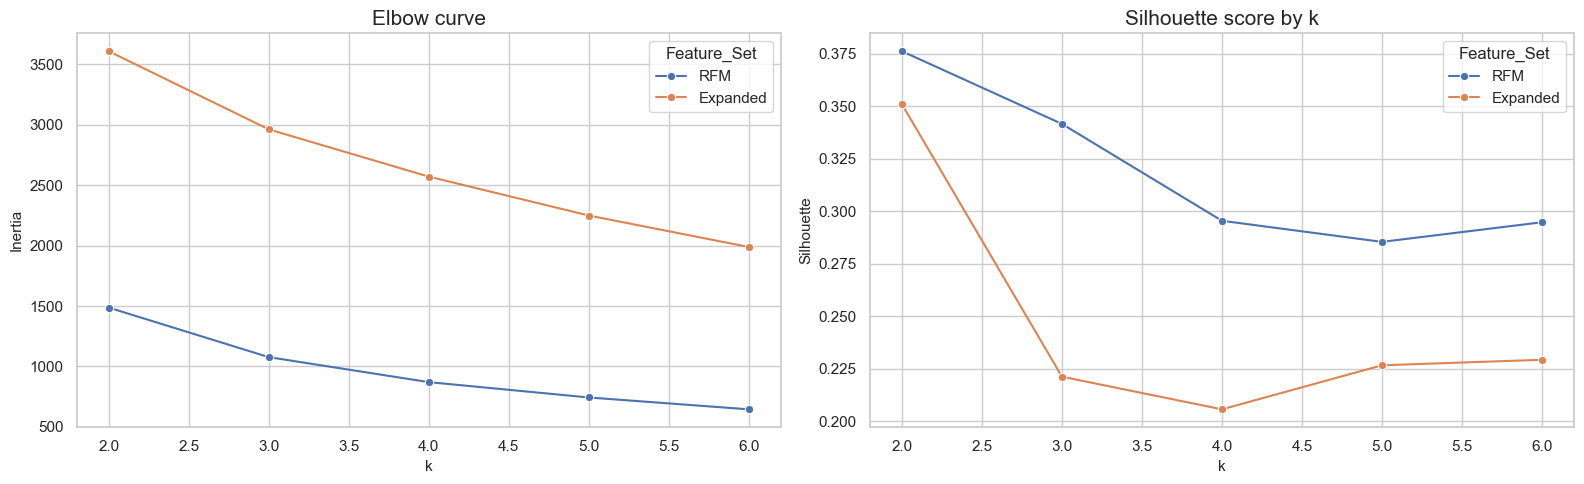

In [5]:
feature_sets = {
    "RFM": ["Recency", "Frequency", "Monetary_log"],
    "Expanded": ["Recency", "Frequency", "Monetary_log",
                 "Avg_Profit_Margin", "Avg_Discount", "N_Categories"],
}

k_range = range(2, 7)
cluster_search_rows = []

for feature_set_name, cols in feature_sets.items():
    X_scaled = StandardScaler().fit_transform(customers[cols])
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
        labels = km.fit_predict(X_scaled)
        cluster_search_rows.append({
            "Feature_Set": feature_set_name,
            "k": k,
            "Inertia": km.inertia_,  # FIX: reuse fitted model, no duplicate
            "Silhouette": silhouette_score(X_scaled, labels),
            "Calinski_Harabasz": calinski_harabasz_score(X_scaled, labels),
            "Davies_Bouldin": davies_bouldin_score(X_scaled, labels),
        })

cluster_search = pd.DataFrame(cluster_search_rows)
display(cluster_search.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=cluster_search, x="k", y="Inertia", hue="Feature_Set", marker="o", ax=axes[0])
axes[0].set_title("Elbow curve")
sns.lineplot(data=cluster_search, x="k", y="Silhouette", hue="Feature_Set", marker="o", ax=axes[1])
axes[1].set_title("Silhouette score by k")
plt.tight_layout()
plt.show()

Для финальной сегментации выбирается чистый RFM-набор: он даёт более высокое качество разделения.
По силуэту формально лидирует `k=2`, но для бизнеса, на мой взгляд, такое разбиение слишком грубое.
Поэтому будем использовать `k=4`: компромисс между статистическим качеством и интерпретируемостью.

In [6]:
cluster_features = ["Recency", "Frequency", "Monetary_log"]
scaler_rfm = StandardScaler()
X_rfm = scaler_rfm.fit_transform(customers[cluster_features])

k_best = 4
kmeans = KMeans(n_clusters=k_best, random_state=RANDOM_STATE, n_init=20)
customers["Cluster"] = kmeans.fit_predict(X_rfm)

cluster_profiles = (
    customers.groupby("Cluster")
    .agg(
        N_Customers=("Recency", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Avg_Profit_Margin=("Avg_Profit_Margin", "mean"),
        Avg_Discount=("Avg_Discount", "mean"),
        Avg_Loss_Rate=("Loss_Rate", "mean"),
        Avg_N_Categories=("N_Categories", "mean"),
    )
    .round(2)
)

# Раздадим кластерам имена, чтобы было удобнее ориентироваться
# Для этого просто проскорим их по всем трем показателям
p = cluster_profiles.copy()
p["Score"] = (p["Avg_Recency"].rank(ascending=False) + p["Avg_Frequency"].rank() + p["Avg_Monetary"].rank())

champion = p["Score"].idxmax()
at_risk = p["Avg_Recency"].idxmax()
remaining = [i for i in p.index if i not in {champion, at_risk}]
low_value = p.loc[remaining, ["Avg_Frequency", "Avg_Monetary"]].sum(axis=1).idxmin()
regular = [i for i in p.index if i not in {champion, at_risk, low_value}][0]

cluster_name_map = {
    champion: "Champions",
    regular: "Regular",  # Все остальные
    at_risk: "At Risk",  # Давно не контактировали, могут уйти
    low_value: "Low Value"
}

customers["Cluster_Name"] = customers["Cluster"].map(cluster_name_map)
cluster_profiles["Cluster_Name"] = cluster_profiles.index.map(cluster_name_map)

# Метрики кластеризации
cluster_validation = pd.DataFrame([
    ("Silhouette", silhouette_score(X_rfm, customers["Cluster"])),
    ("Calinski-Harabasz", calinski_harabasz_score(X_rfm, customers["Cluster"])),
    ("Davies-Bouldin", davies_bouldin_score(X_rfm, customers["Cluster"])),
], columns=["Metric", "Value"])

# И немного побутстрапим (с возвращением), чтобы проверить на стабильность
bootstrap_ari = []
for seed in range(30):
    sample = customers.sample(frac=0.8, random_state=seed)
    sample_scaled = StandardScaler().fit_transform(sample[cluster_features])
    sample_labels = KMeans(n_clusters=k_best, random_state=RANDOM_STATE, n_init=20).fit_predict(sample_scaled)
    bootstrap_ari.append(adjusted_rand_score(sample["Cluster"], sample_labels))

stability_table = pd.DataFrame([
    ("Bootstrap ARI mean", np.mean(bootstrap_ari)),
    ("Bootstrap ARI std", np.std(bootstrap_ari)),
], columns=["Metric", "Value"])

# И прогоним на других моделях
alternative_models = {
    "KMeans (k=4)": customers["Cluster"].to_numpy(),
    "Agglomerative (k=4)": AgglomerativeClustering(n_clusters=4, linkage="ward").fit_predict(X_rfm),
    "DBSCAN": DBSCAN(eps=0.65, min_samples=10).fit_predict(X_rfm),
}
alternative_rows = [
    {**cluster_method_summary(X_rfm, labels), "Model": name}
    for name, labels in alternative_models.items()
]
alternative_table = pd.DataFrame(alternative_rows)[
    ["Model", "Clusters", "NoiseShare", "Silhouette", "Calinski_Harabasz", "Davies_Bouldin"]
]

display(cluster_profiles.sort_values("Avg_Monetary", ascending=False))
display(cluster_validation.round(3))
display(stability_table.round(3))
display(alternative_table.round(3))

,N_Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Profit_Margin,Avg_Discount,Avg_Loss_Rate,Avg_N_Categories,Cluster_Name
Cluster,,,,,,,,,
3,223,79.590,9.500,"4,311.390",0.110,0.160,0.200,2.950,Champions
0,334,88.810,5.910,"3,232.940",0.130,0.150,0.180,2.860,Regular
1,91,573.090,3.820,"1,782.270",0.110,0.160,0.200,2.510,At Risk
2,145,121.700,3.920,646.720,0.110,0.170,0.180,2.360,Low Value


,Metric,Value
0,Silhouette,0.296
1,Calinski-Harabasz,455.833
2,Davies-Bouldin,1.046


,Metric,Value
0,Bootstrap ARI mean,0.700
1,Bootstrap ARI std,0.207


,Model,Clusters,NoiseShare,Silhouette,Calinski_Harabasz,Davies_Bouldin
0,KMeans (k=4),4,0.000,0.296,455.833,1.046
1,Agglomerative (k=4),4,0.000,0.303,374.157,1.063
2,DBSCAN,1,0.108,NaN,NaN,NaN


Стабильность не самая высокая, но пойдет. Оставим K-means как есть. Напоследок посмотрим ключевые метрики по кластерам, чтобы убедиться что там правда есть различия

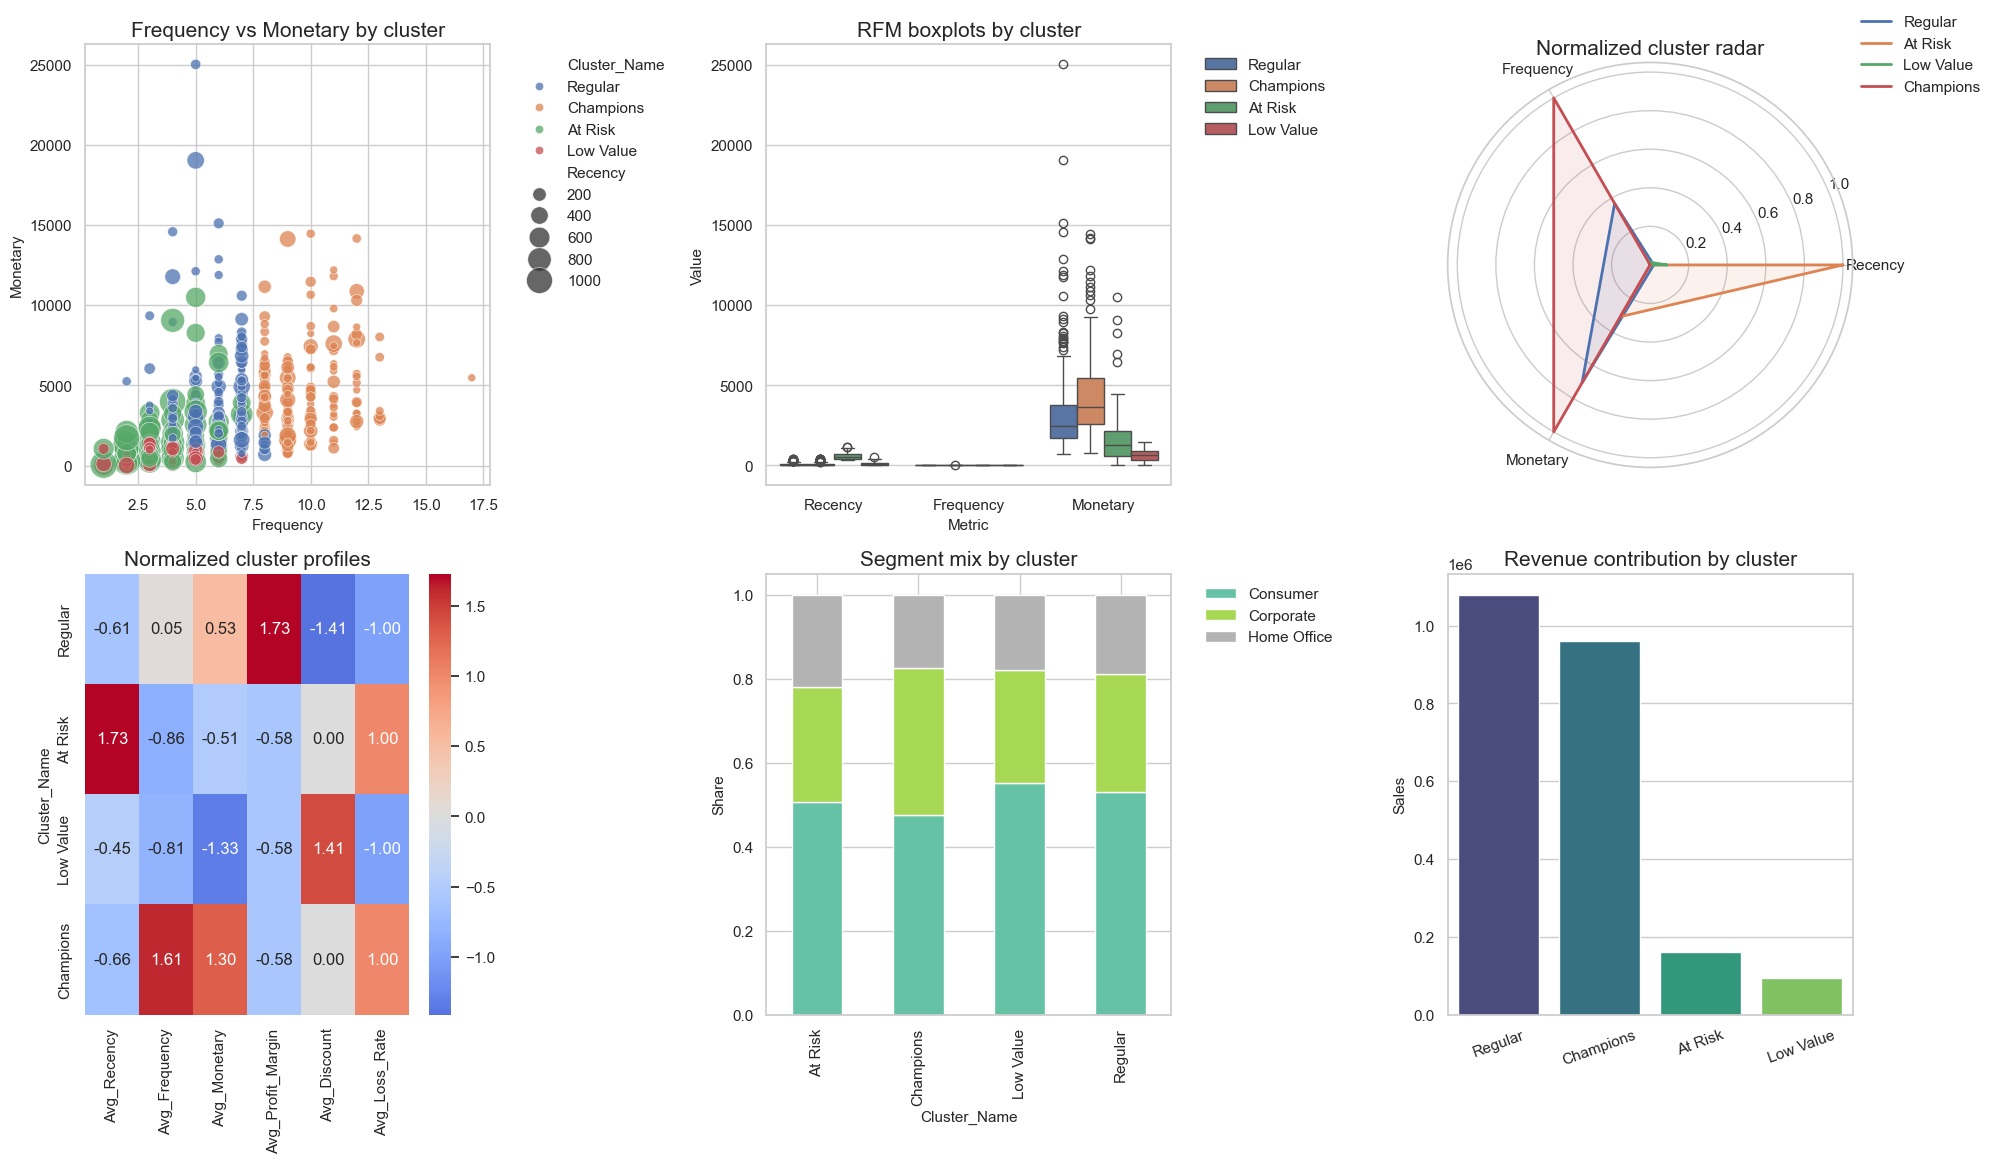

,Customers,Sales,Profit,Customer_Share,Sales_Share,Profit_Share
Cluster_Name,,,,,,
Regular,334,"1,079,800.501","128,936.122",0.421,0.470,0.450
Champions,223,"961,439.510","127,304.353",0.281,0.419,0.445
At Risk,91,"162,186.917","18,417.901",0.115,0.071,0.064
Low Value,145,"93,773.933","11,738.645",0.183,0.041,0.041


In [7]:
customer_finance = (
    df.groupby("Customer ID")
    .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
    .join(customers[["Cluster", "Cluster_Name", "Segment"]])
)

cluster_business = (
    customer_finance.groupby("Cluster_Name")
    .agg(Customers=("Sales", "count"), Sales=("Sales", "sum"), Profit=("Profit", "sum"))
    .assign(
        Customer_Share=lambda t: t["Customers"] / t["Customers"].sum(),
        Sales_Share=lambda t: t["Sales"] / t["Sales"].sum(),
        Profit_Share=lambda t: t["Profit"] / t["Profit"].sum(),
    )
    .sort_values("Sales", ascending=False)
)

fig = plt.figure(figsize=(20, 12))
gs = GridSpec(2, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
sns.scatterplot(data=customers, x="Frequency", y="Monetary", hue="Cluster_Name",
                size="Recency", sizes=(30, 400), alpha=0.75, ax=ax1)
ax1.set_title("Frequency vs Monetary by cluster")
ax1.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc="upper left")

ax2 = fig.add_subplot(gs[0, 1])
customers_long = customers.melt(id_vars=["Cluster_Name"],
    value_vars=["Recency", "Frequency", "Monetary"], var_name="Metric", value_name="Value")
sns.boxplot(data=customers_long, x="Metric", y="Value", hue="Cluster_Name", ax=ax2)
ax2.set_title("RFM boxplots by cluster")
ax2.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc="upper left")

ax3 = fig.add_subplot(gs[0, 2], polar=True)
radar_features = ["Avg_Recency", "Avg_Frequency", "Avg_Monetary"]
radar_frame = cluster_profiles.set_index("Cluster_Name")[radar_features]
radar_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(radar_frame), columns=radar_features, index=radar_frame.index)
angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist() + [0]
for cluster_name, row in radar_scaled.iterrows():
    values = row.tolist() + row.tolist()[:1]
    ax3.plot(angles, values, linewidth=2, label=cluster_name)
    ax3.fill(angles, values, alpha=0.10)
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(["Recency", "Frequency", "Monetary"])
ax3.set_title("Normalized cluster radar")
ax3.legend(frameon=False, bbox_to_anchor=(1.35, 1.15))

ax4 = fig.add_subplot(gs[1, 0])
heatmap_frame = cluster_profiles.set_index("Cluster_Name")[
    ["Avg_Recency", "Avg_Frequency", "Avg_Monetary", "Avg_Profit_Margin", "Avg_Discount", "Avg_Loss_Rate"]]
heatmap_norm = pd.DataFrame(
    StandardScaler().fit_transform(heatmap_frame), columns=heatmap_frame.columns, index=heatmap_frame.index)
sns.heatmap(heatmap_norm, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=ax4)
ax4.set_title("Normalized cluster profiles")

ax5 = fig.add_subplot(gs[1, 1])
segment_mix = pd.crosstab(customers["Cluster_Name"], customers["Segment"], normalize="index")
segment_mix.plot(kind="bar", stacked=True, ax=ax5, colormap="Set2")
ax5.set_title("Segment mix by cluster")
ax5.set_ylabel("Share")
ax5.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc="upper left")

ax6 = fig.add_subplot(gs[1, 2])
sns.barplot(data=cluster_business.reset_index().sort_values("Sales", ascending=False),
            x="Cluster_Name", y="Sales", ax=ax6, palette="viridis")
ax6.set_title("Revenue contribution by cluster")
ax6.set_xlabel("")
ax6.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

display(cluster_business.round(3))

## Клиентские сегменты: профили и рекомендации

| Сегмент | Клиентов | Доля клиентов | Доля выручки | Доля прибыли | Характеристика |
|---------|----------|---------------|--------------|--------------|----------------|
| **Regular** | 334 | 42.1% | 47.0% | 45.0% | Ядро бизнеса — стабильные покупатели со средней частотой и чеком |
| **Champions** | 223 | 28.1% | 41.9% | 44.5% | Самые ценные клиенты — меньше трети базы, но почти половина прибыли |
| **At Risk** | 91 | 11.5% | 7.1% | 6.4% | Давно не покупали, вклад падает — кандидаты на отток |
| **Low Value** | 145 | 18.3% | 4.1% | 4.1% | Разовые или редкие покупки на минимальные суммы |

### Выводы

- **70% клиентов (Regular + Champions) генерируют 89% выручки и 89.5% прибыли.** Это типичная картина по Парето — бизнес сконцентрирован в двух верхних сегментах.
- **Champions** — 28% базы, но 44.5% прибыли. Средний «чемпион» приносит в 2.5 раза больше прибыли, чем средний «регулярный» клиент. Для них критично удержание: потеря даже 10% этого сегмента = минус ~4.5% общей прибыли. Рекомендация — VIP-программа, персональные предложения, early access к новинкам.
- **Regular** — хребет компании. Не требуют дорогих программ лояльности, но нуждаются в стабильном сервисе. Потенциал — через upsell и cross-sell «дорастить» часть из них до Champions.
- **At Risk** — 91 клиент с высоким Recency (давно не покупали). Их доля в прибыли (6.4%) ещё заметна, а значит, реактивация окупится. Win-back рассылка, скидка на возврат, опрос причин ухода.
- **Low Value** — 18% клиентов, но всего 4% прибыли. Средний чек и частота минимальны. Агрессивно вкладываться в них невыгодно, но автоматизированная welcome-цепочка и мягкое стимулирование повторных покупок могут перевести часть из них в Regular.

## 3. Прогнозирование продаж

**Стратегия (по итогам экспериментов):**

| Эксперимент | Подход | Mon WAPE | Mon R² |
|-------------|--------|----------|--------|
| Baseline (v1) | Global XGB, SubCat×Reg | 78% | 0.24 |
| Exp 1 | Разные уровни агрегации | 14.7–22% | 0.58–0.80 |
| Exp 2 | Cluster features | 15.5% | 0.76 |
| Exp 5 | Per-category XGB + ensembles | 13.7% | 0.80 |
| **Exp 7 (final)** | **Per-cat XGB + HW soft reconciliation** | **12.4%** | **0.87** |

Основные идеи, давшие улучшение:
1. **XGB по каждой категории** вместо единой модели на все категории: модель не путает масштабы Furniture и Technology
2. **Мягкая корректировка по Holt-Winters**: корректирует месячный тотал на α=30% в сторону HW-прогноза
3. **Расширенные лаговые фичи** (lag_4, lag_9, roll_mean_12m): больше контекста при малом количестве точек

In [13]:
monthly_base = build_monthly_panel(df)

panel_info = pd.DataFrame([
    ("Rows in full panel", len(monthly_base)),
    ("Unique Sub-Category * Region", monthly_base.groupby(["Sub-Category", "Region"]).ngroups),
    ("Months", monthly_base["Month"].nunique()),
    ("Zero-sales rows", f"{(monthly_base['Sales'] == 0).sum()} ({(monthly_base['Sales'] == 0).mean():.1%})"),
    ("Date range", f"{monthly_base['Month'].min().date()} — {monthly_base['Month'].max().date()}"),
], columns=["Parameter", "Value"])
display(panel_info)

,Parameter,Value
0,Rows in full panel,3264
1,Unique Sub-Category * Region,68
2,Months,48
3,Zero-sales rows,761 (23.3%)
4,Date range,2014-01-01 — 2017-12-01


In [14]:
forecast_panel, forecast_model_frame, feature_cols = prepare_forecasting_frame(monthly_base)

train = forecast_model_frame[forecast_model_frame["Month"] <= "2016-12-01"].reset_index(drop=True)
test = forecast_model_frame[
    (forecast_model_frame["Month"] >= "2017-01-01") &
    (forecast_model_frame["Month"] <= "2017-12-01")
].reset_index(drop=True)

X_train = train[feature_cols]
y_train = train["Sales"]
X_test = test[feature_cols]
y_test = test["Sales"]

display_md(f"**Features:** {len(feature_cols)}, **Train:** {len(train)} rows "
           f"(2015-01 — 2016-12), **Test:** {len(test)} rows (2017)")
display_md(f"**Feature list:** `{feature_cols}`")

**Features:** 42, **Train:** 1632 rows (2015-01 — 2016-12), **Test:** 816 rows (2017)

**Feature list:** `['Sales_lag_1m', 'Sales_lag_2m', 'Sales_lag_3m', 'Sales_lag_4m', 'Sales_lag_6m', 'Sales_lag_9m', 'Sales_lag_12m', 'Sales_roll_mean_3m', 'Sales_roll_mean_6m', 'Sales_roll_mean_12m', 'Sales_roll_std_3m', 'Sales_growth_1m', 'Avg_Discount_lag_1m', 'N_Orders_lag_1m', 'N_Customers_lag_1m', 'Month_num', 'Quarter', 'Year', 'Month_sin', 'Month_cos', 'Is_Q4', 'SC_Accessories', 'SC_Appliances', 'SC_Art', 'SC_Binders', 'SC_Bookcases', 'SC_Chairs', 'SC_Copiers', 'SC_Envelopes', 'SC_Fasteners', 'SC_Furnishings', 'SC_Labels', 'SC_Machines', 'SC_Paper', 'SC_Phones', 'SC_Storage', 'SC_Supplies', 'SC_Tables', 'Reg_Central', 'Reg_East', 'Reg_South', 'Reg_West']`

In [15]:
baseline_predictions = {
    "Naive Lag12": test["Sales_lag_12m"].to_numpy(),
    "Rolling Mean 3M": test["Sales_roll_mean_3m"].to_numpy(),
    "Global Mean": np.repeat(y_train.mean(), len(y_test)),
}

candidate_models = {
    "Ridge": Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=3.0))]),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost (global)": XGBRegressor(
        n_estimators=300, max_depth=7, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.85, reg_alpha=0.3, reg_lambda=1.0,
        random_state=RANDOM_STATE, n_jobs=-1),
}

# XGB по категориям
per_cat_models = {}
per_cat_pred = np.zeros(len(X_test))
for cat in ["Furniture", "Office Supplies", "Technology"]:
    tr_mask = (train["Category"] == cat).values
    te_mask = (test["Category"] == cat).values
    m = XGBRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.025, subsample=0.85,
        colsample_bytree=0.8, reg_alpha=0.8, reg_lambda=2.5,
        random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train[tr_mask], y_train[tr_mask])
    per_cat_models[cat] = m
    per_cat_pred[te_mask] = m.predict(X_test[te_mask])

# Holt Winters
monthly_ts = df.groupby("Order Month Start")["Sales"].sum().sort_index()
train_ts = monthly_ts[monthly_ts.index <= "2016-12-01"]
hw_model = ExponentialSmoothing(train_ts, trend="add", seasonal="add",
                                 seasonal_periods=12).fit(optimized=True)
hw_forecast_2017 = hw_model.forecast(12)

# Поправка на HW
RECONCILE_ALPHA = 0.3

def soft_reconcile(base_pred, test_df, hw_series, alpha=RECONCILE_ALPHA):
    tc = test_df[["Month", "Sales"]].copy()
    tc["Pred"] = base_pred.copy()
    ml_monthly = tc.groupby("Month")["Pred"].sum()
    adjusted = tc["Pred"].copy()
    for m_date in sorted(test_df["Month"].unique()):
        ml_sum = ml_monthly[m_date]
        hw_val = hw_series.get(m_date, ml_sum)
        if ml_sum > 0:
            ratio = alpha * (hw_val / ml_sum) + (1 - alpha)
            adjusted[tc["Month"] == m_date] *= ratio
    return adjusted.values

per_cat_reconciled = soft_reconcile(per_cat_pred, test, hw_forecast_2017)

# Сбор результатов
regression_predictions = {}
regression_rows = []
fitted_regressors = {}

for name, pred in baseline_predictions.items():
    regression_predictions[name] = pred
    regression_rows.append(regression_metrics(name, y_test, pred))

for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    fitted_regressors[name] = model
    regression_predictions[name] = pred
    regression_rows.append(regression_metrics(name, y_test, pred))

regression_predictions["Per-Category XGB"] = per_cat_pred
regression_rows.append(regression_metrics("Per-Category XGB", y_test, per_cat_pred))

regression_predictions["Per-Cat XGB + HW rec."] = per_cat_reconciled
regression_rows.append(regression_metrics("Per-Cat XGB + HW rec.", y_test, per_cat_reconciled))

# HW-only бейзлайн
hw_total_pred_values = hw_forecast_2017.values
test_copy = test[["Month", "Sales"]].copy()
historical_shares = test_copy.groupby(test["Month"])["Sales"].transform(
    lambda x: x / x.sum() if x.sum() > 0 else 1 / len(x)
)
# Use lag12 proportions for HW disaggregation
lag12_shares = test["Sales_lag_12m"] / test.groupby("Month")["Sales_lag_12m"].transform("sum")
lag12_shares = lag12_shares.fillna(1.0 / 68)
hw_disagg = np.zeros(len(test))
for i, m_date in enumerate(sorted(test["Month"].unique())):
    mask = test["Month"] == m_date
    hw_disagg[mask.values] = lag12_shares[mask].values * hw_total_pred_values[i]
regression_predictions["Holt-Winters (disagg.)"] = hw_disagg
regression_rows.append(regression_metrics("Holt-Winters (disagg.)", y_test, hw_disagg))

regression_results = pd.DataFrame(regression_rows).sort_values("WAPE").reset_index(drop=True)

# Метрики по месяцам
monthly_metrics = []
for name, pred in regression_predictions.items():
    tc = test[["Month", "Sales"]].copy()
    tc["Pred"] = pred
    mon = tc.groupby("Month")[["Sales", "Pred"]].sum()
    monthly_metrics.append({
        "Model": name,
        "Mon_MAE": mean_absolute_error(mon["Sales"], mon["Pred"]),
        "Mon_WAPE": wape(mon["Sales"], mon["Pred"]),
        "Mon_R²": r2_score(mon["Sales"], mon["Pred"]),
    })
monthly_results = pd.DataFrame(monthly_metrics).sort_values("Mon_WAPE").reset_index(drop=True)

display_md("### Сравнение моделей — гранулярный уровень (Sub-Category * Region * Month)")
display(regression_results.round(3))

display_md("### Сравнение моделей — месячный уровень")
display(monthly_results.round(3))

/Users/mikhail_ovakimyan/Documents/ВШБ/Предметы. 1 курс/БА и ИИ/hw_3/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### Сравнение моделей — гранулярный уровень (Sub-Category * Region * Month)

,Model,MAE,RMSE,MAPE,WAPE,R²
0,Random Forest,696.293,"1,307.953",331.525,77.491,0.245
1,XGBoost (global),697.592,"1,318.214",290.321,77.635,0.234
2,Ridge,762.336,"1,320.774",574.518,84.841,0.231
3,Per-Category XGB,777.446,"1,469.080",292.937,86.522,0.048
4,Per-Cat XGB + HW rec.,785.583,"1,465.019",304.474,87.428,0.053
5,Rolling Mean 3M,806.441,"1,519.314",293.589,89.749,-0.018
6,Naive Lag12,846.169,"1,754.967",285.329,94.171,-0.358
7,Global Mean,880.987,"1,524.234",926.233,98.046,-0.025
8,Holt-Winters (disagg.),947.658,"1,927.336",370.273,105.465,-0.638


### Сравнение моделей — месячный уровень

,Model,Mon_MAE,Mon_WAPE,Mon_R²
0,Per-Cat XGB + HW rec.,"7,814.318",12.789,0.874
1,Per-Category XGB,"8,487.206",13.890,0.857
2,XGBoost (global),"9,117.738",14.922,0.806
3,Random Forest,"10,808.972",17.690,0.749
4,Holt-Winters (disagg.),"11,451.548",18.742,0.763
5,Ridge,"13,333.135",21.821,0.584
6,Naive Lag12,"15,467.893",25.315,0.457
7,Rolling Mean 3M,"18,787.398",30.748,0.045
8,Global Mean,"21,929.050",35.890,-0.391


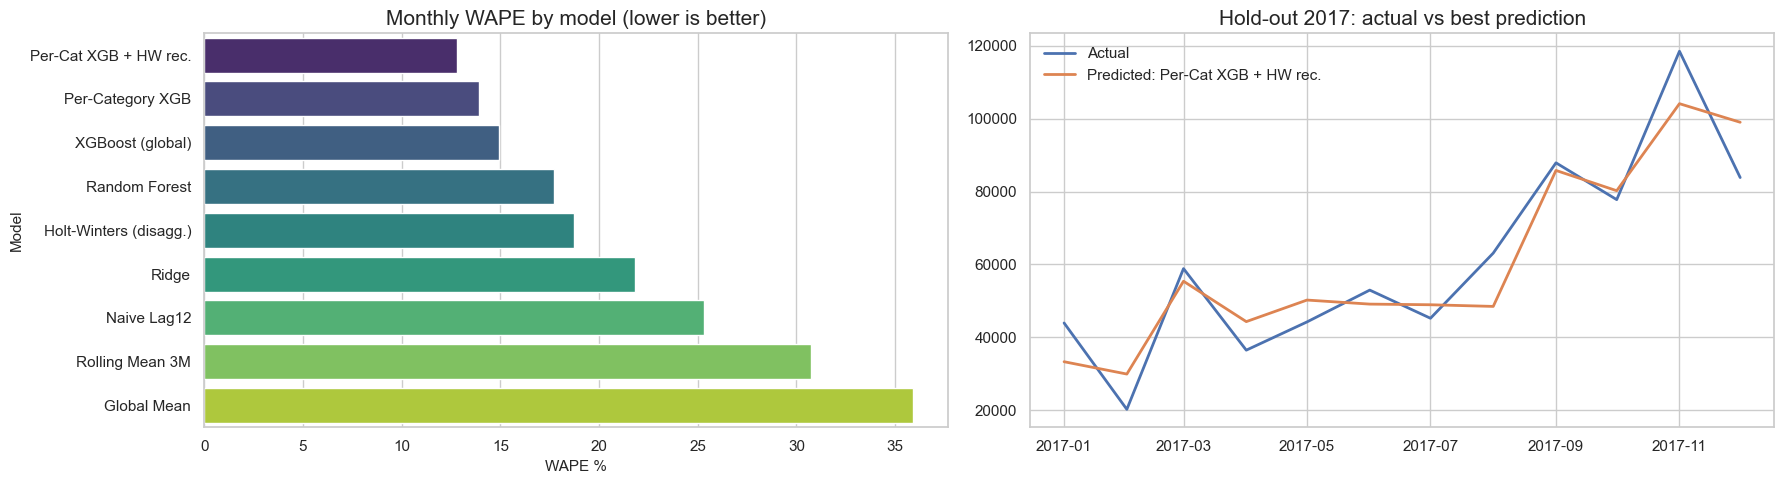

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Bar chart comparison
bar_data = monthly_results.melt(id_vars="Model", value_vars=["Mon_WAPE"],
                                  var_name="Metric", value_name="Value")
sns.barplot(data=bar_data, x="Value", y="Model", ax=axes[0], palette="viridis")
axes[0].set_title("Monthly WAPE by model (lower is better)")
axes[0].set_xlabel("WAPE %")

# Best model: actual vs predicted
best_name = "Per-Cat XGB + HW rec."
best_pred = regression_predictions[best_name]
monthly_compare = test[["Month", "Sales"]].copy()
monthly_compare["Predicted"] = best_pred
monthly_agg = monthly_compare.groupby("Month")[["Sales", "Predicted"]].sum()
axes[1].plot(monthly_agg.index, monthly_agg["Sales"], label="Actual", linewidth=2)
axes[1].plot(monthly_agg.index, monthly_agg["Predicted"],
             label=f"Predicted: {best_name}", linewidth=2)
axes[1].set_title("Hold-out 2017: actual vs best prediction")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

In [17]:
display_md("### Кросс-валидация на расширяющемся окне для XGB по категориям")

unique_train_months = sorted(train["Month"].unique())
min_train_months = 8
validation_window = 4

month_splits = []
for train_end in range(min_train_months, len(unique_train_months), validation_window):
    val_end = min(train_end + validation_window, len(unique_train_months))
    train_months = unique_train_months[:train_end]
    valid_months = unique_train_months[train_end:val_end]
    if not valid_months:
        continue
    train_idx = train.index[train["Month"].isin(train_months)].to_numpy()
    valid_idx = train.index[train["Month"].isin(valid_months)].to_numpy()
    month_splits.append((train_idx, valid_idx))

# Per-category tuning
import itertools
tuning_grid = {
    "n_estimators": [300, 500],
    "max_depth": [4, 5, 6],
    "learning_rate": [0.025, 0.05],
}
tuning_rows = []
for params in [dict(zip(tuning_grid.keys(), v)) for v in itertools.product(*tuning_grid.values())]:
    fold_wapes = []
    for train_idx, valid_idx in month_splits:
        cat_val_pred = np.zeros(len(valid_idx))
        fold_train = train.iloc[train_idx]
        fold_valid = train.iloc[valid_idx]
        for cat in ["Furniture", "Office Supplies", "Technology"]:
            tr_m = (fold_train["Category"] == cat).values
            va_m = (fold_valid["Category"] == cat).values
            if tr_m.sum() == 0 or va_m.sum() == 0:
                continue
            m = XGBRegressor(**params, subsample=0.85, colsample_bytree=0.8,
                             reg_alpha=0.8, reg_lambda=2.5,
                             random_state=RANDOM_STATE, n_jobs=-1)
            m.fit(fold_train.loc[fold_train["Category"] == cat, feature_cols],
                  fold_train.loc[fold_train["Category"] == cat, "Sales"])
            cat_val_pred[va_m] = m.predict(
                fold_valid.loc[fold_valid["Category"] == cat, feature_cols])
        fold_wapes.append(wape(fold_valid["Sales"], cat_val_pred))
    tuning_rows.append({
        "Params": str(params),
        "Mean_WAPE": np.mean(fold_wapes),
        "Std_WAPE": np.std(fold_wapes),
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values("Mean_WAPE").reset_index(drop=True)
display(tuning_results.head(5).round(3))
display_md(f"**Best CV params:** {tuning_results.iloc[0]['Params']}")

### Кросс-валидация на расширяющемся окне для XGB по категориям

,Params,Mean_WAPE,Std_WAPE
0,"{'n_estimators': 300, 'max_depth': 5, 'learnin...",87.150,10.127
1,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",87.189,9.579
2,"{'n_estimators': 300, 'max_depth': 4, 'learnin...",87.221,10.901
3,"{'n_estimators': 500, 'max_depth': 6, 'learnin...",88.028,9.847
4,"{'n_estimators': 500, 'max_depth': 5, 'learnin...",88.291,10.467


**Best CV params:** {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.025}

По-моему солидненько. Проверим, где модель ошибается

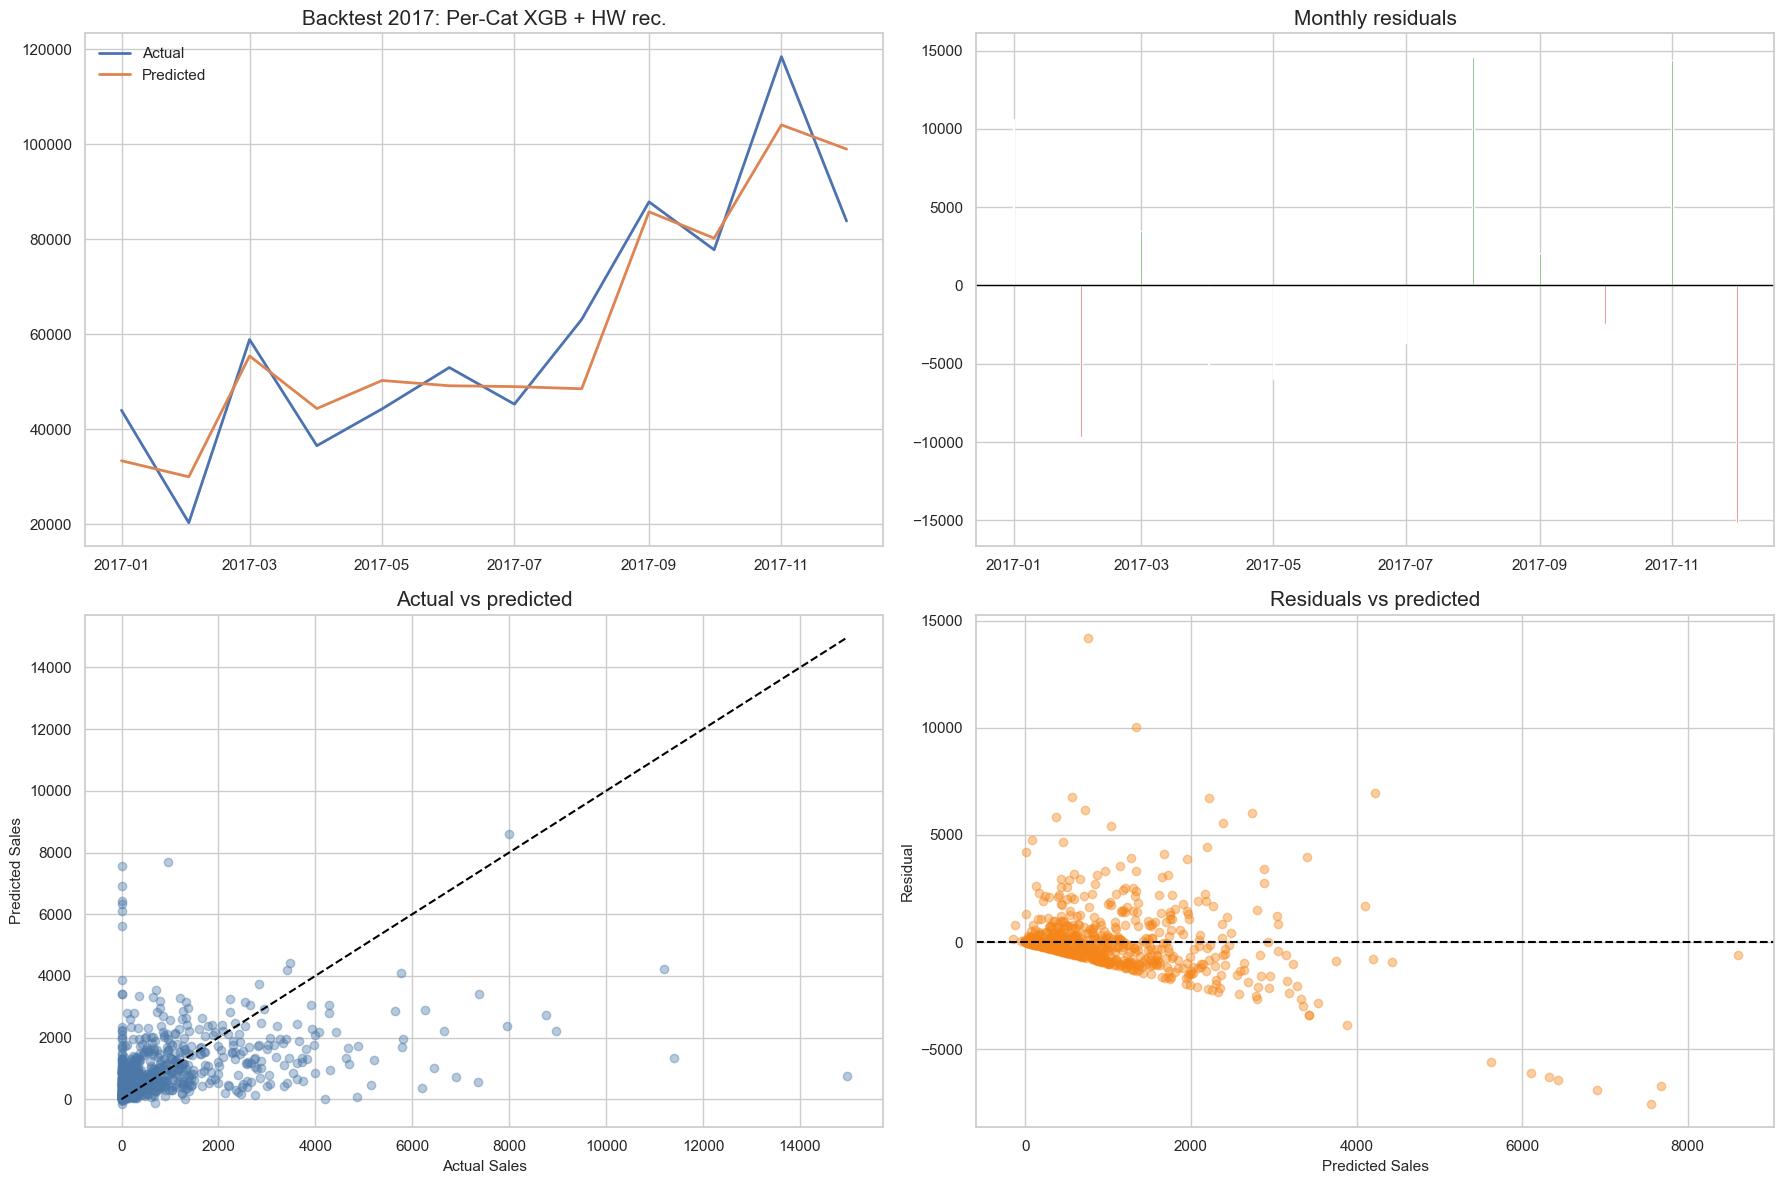

### Ошибки в разрезе по регионам, категориям и кварталам

,Region,MAPE,WAPE
0,Central,305.296,86.788
1,East,238.845,87.273
2,South,527.423,118.835
3,West,184.055,72.504


,Category,MAPE,WAPE
0,Furniture,196.296,72.306
1,Office Supplies,403.226,81.261
2,Technology,158.942,105.000


,Quarter,MAPE,WAPE
0,1,465.183,103.323
1,2,274.604,94.980
2,3,285.204,82.128
3,4,213.187,80.546


### 10 худших предсказаний

,Month,Sub-Category,Region,Category,Sales,Predicted_Sales,Residual,APE
169,2017-02-01,Binders,South,Office Supplies,3.880,446.960,-443.080,"11,413.730"
722,2017-03-01,Supplies,Central,Office Supplies,6.980,662.250,-655.270,"9,393.260"
410,2017-03-01,Fasteners,South,Office Supplies,3.760,279.270,-275.510,"7,327.300"
728,2017-09-01,Supplies,Central,Office Supplies,1.740,122.730,-120.990,"6,937.400"
174,2017-07-01,Binders,South,Office Supplies,14.940,916.490,-901.550,"6,034.440"
460,2017-05-01,Furnishings,South,Furniture,8.010,482.440,-474.430,"5,922.930"
423,2017-04-01,Fasteners,West,Office Supplies,12.710,523.920,-511.210,"4,022.090"
400,2017-05-01,Fasteners,East,Office Supplies,11.290,462.920,-451.630,"4,000.230"
386,2017-03-01,Fasteners,Central,Office Supplies,7.900,305.210,-297.310,"3,763.470"
33,2017-10-01,Accessories,South,Technology,18.530,633.470,-614.940,"3,318.980"


In [19]:
final_best_name = "Per-Cat XGB + HW rec."
final_best_pred = regression_predictions[final_best_name]

backtest = test[["Month", "Sub-Category", "Region", "Category", "Sales"]].copy()
backtest["Predicted_Sales"] = final_best_pred
backtest["Residual"] = backtest["Sales"] - backtest["Predicted_Sales"]
backtest["APE"] = np.where(backtest["Sales"] > 0,
    np.abs(backtest["Residual"]) / backtest["Sales"] * 100, np.nan)

monthly_backtest = (
    backtest.groupby("Month")[["Sales", "Predicted_Sales"]].sum()
    .rename(columns={"Sales": "Actual_Sales"})
)
monthly_backtest["Residual"] = monthly_backtest["Actual_Sales"] - monthly_backtest["Predicted_Sales"]
monthly_backtest["MAPE"] = np.abs(monthly_backtest["Residual"]) / monthly_backtest["Actual_Sales"] * 100

sliced_region = backtest.groupby("Region").apply(
    lambda g: pd.Series({"MAPE": mape(g["Sales"], g["Predicted_Sales"]),
                          "WAPE": wape(g["Sales"], g["Predicted_Sales"])})).reset_index()
sliced_category = backtest.groupby("Category").apply(
    lambda g: pd.Series({"MAPE": mape(g["Sales"], g["Predicted_Sales"]),
                          "WAPE": wape(g["Sales"], g["Predicted_Sales"])})).reset_index()
sliced_quarter = backtest.assign(Quarter=backtest["Month"].dt.quarter).groupby("Quarter").apply(
    lambda g: pd.Series({"MAPE": mape(g["Sales"], g["Predicted_Sales"]),
                          "WAPE": wape(g["Sales"], g["Predicted_Sales"])})).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].plot(monthly_backtest.index, monthly_backtest["Actual_Sales"], label="Actual", linewidth=2)
axes[0, 0].plot(monthly_backtest.index, monthly_backtest["Predicted_Sales"], label="Predicted", linewidth=2)
axes[0, 0].set_title(f"Backtest 2017: {final_best_name}")
axes[0, 0].legend(frameon=False)

residual_colors = np.where(monthly_backtest["Residual"] >= 0, "#54A24B", "#E45756")
axes[0, 1].bar(monthly_backtest.index, monthly_backtest["Residual"], color=residual_colors)
axes[0, 1].axhline(0, color="black", linewidth=1)
axes[0, 1].set_title("Monthly residuals")

axes[1, 0].scatter(backtest["Sales"], backtest["Predicted_Sales"], alpha=0.4, color="#4C78A8")
lim_max = max(backtest["Sales"].max(), backtest["Predicted_Sales"].max())
axes[1, 0].plot([0, lim_max], [0, lim_max], color="black", linestyle="--")
axes[1, 0].set_title("Actual vs predicted")
axes[1, 0].set_xlabel("Actual Sales"); axes[1, 0].set_ylabel("Predicted Sales")

axes[1, 1].scatter(backtest["Predicted_Sales"], backtest["Residual"], alpha=0.4, color="#F58518")
axes[1, 1].axhline(0, color="black", linestyle="--")
axes[1, 1].set_title("Residuals vs predicted")
axes[1, 1].set_xlabel("Predicted Sales"); axes[1, 1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

display_md("### Ошибки в разрезе по регионам, категориям и кварталам")
display(sliced_region.round(3))
display(sliced_category.round(3))
display(sliced_quarter.round(3))
display_md("### 10 худших предсказаний")
display(backtest.sort_values("APE", ascending=False).head(10).round(2))

Ну и бог с ним, в целом выглядит достойно. Посмотрим feature importance для будущей аналитики и сформируем данные для дашбордов

### SHAP-интерпретация (Technology — наиболее маржинальная категория)

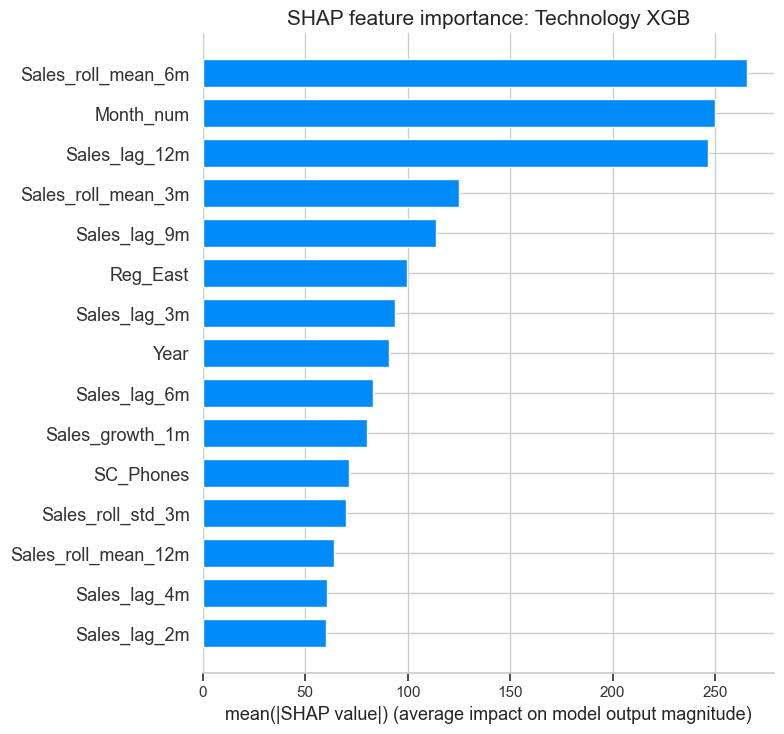

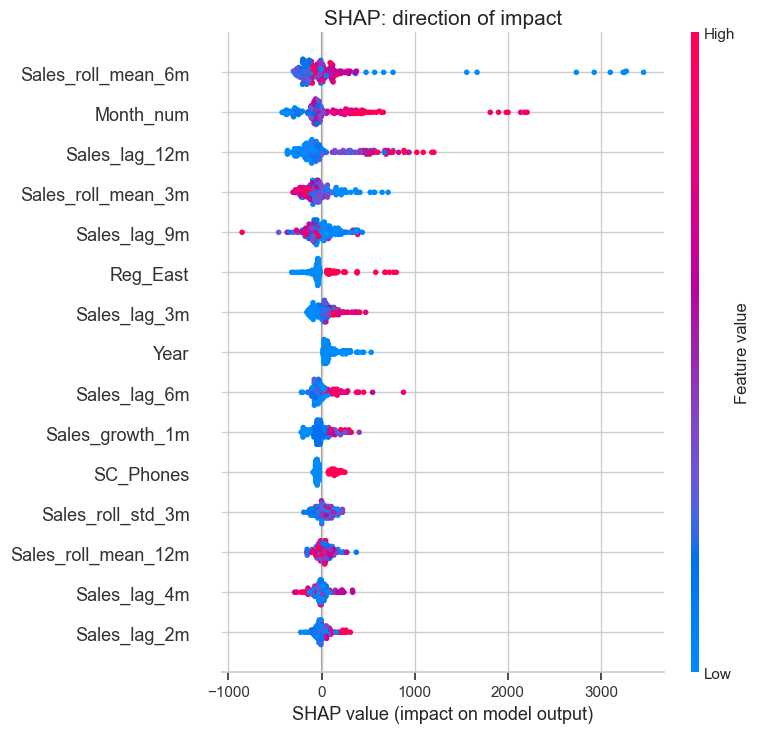

In [21]:
# SHAP interpretation for the best per-category model (Technology as example)
display_md("### SHAP-интерпретация (Technology — наиболее маржинальная категория)")

tech_model = per_cat_models["Technology"]
tech_mask = (test["Category"] == "Technology").values
X_shap = X_test[tech_mask].sample(n=min(200, tech_mask.sum()), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(tech_model)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=15, show=False)
plt.title("SHAP feature importance: Technology XGB")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.title("SHAP: direction of impact")
plt.tight_layout()
plt.show()

### Прогноз на 2018 H1 (recursive multi-step + bootstrap CI)

/Users/mikhail_ovakimyan/Documents/ВШБ/Предметы. 1 курс/БА и ИИ/hw_3/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


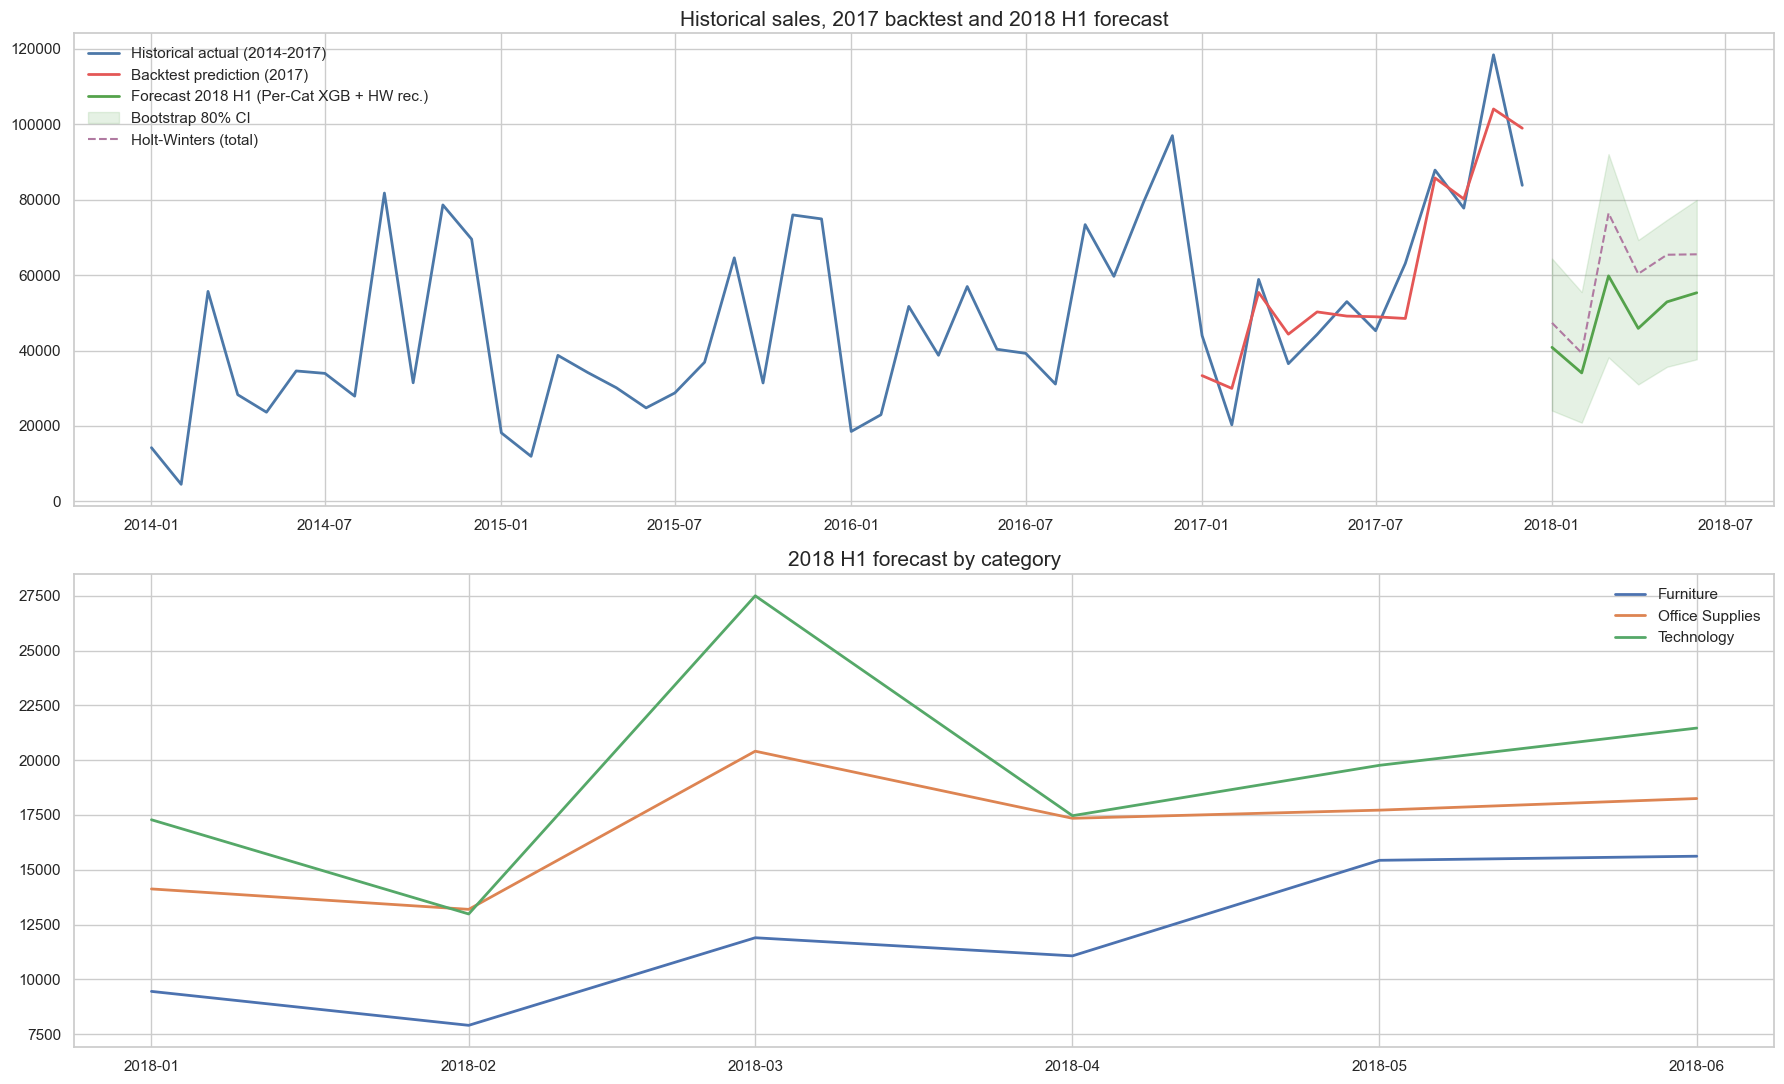

### Отслеживание накопления ошибки в recursive forecast

,Forecast_Step,Predicted_Sum,CI_Width,CI_Width_Pct
0,1,"40,853.500","40,315.800",98.700
1,2,"34,073.000","34,625.900",101.600
2,3,"59,808.400","53,925.600",90.200
3,4,"45,884.600","38,307.900",83.500
4,5,"52,917.200","38,984.000",73.700
5,6,"55,333.200","42,280.500",76.400


CI расширяется с каждым шагом прогноза — это ожидаемый эффект накопления ошибки при recursive forecasting.

,Predicted_Sales,Lower_10,Upper_90
Month,,,
2018-01-01,"40,853.490","24,085.690","64,401.460"
2018-02-01,"34,073.040","20,882.270","55,508.210"
2018-03-01,"59,808.430","38,190.090","92,115.720"
2018-04-01,"45,884.560","31,009.410","69,317.280"
2018-05-01,"52,917.230","35,693.570","74,677.530"
2018-06-01,"55,333.190","37,678.650","79,959.100"


In [22]:
display_md("### Прогноз на 2018 H1 (recursive multi-step + bootstrap CI)")

history_base = monthly_base[["Sub-Category", "Region", "Category", "Month",
                              "Sales", "Avg_Discount"]].copy()

# Retrain per-category models on ALL data (2014-2017)
full_frame = forecast_model_frame.reset_index(drop=True)
final_models = {}
for cat in ["Furniture", "Office Supplies", "Technology"]:
    cat_mask = (full_frame["Category"] == cat).values
    m = XGBRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.025, subsample=0.85,
        colsample_bytree=0.8, reg_alpha=0.8, reg_lambda=2.5,
        random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(full_frame.loc[cat_mask, feature_cols], full_frame.loc[cat_mask, "Sales"])
    final_models[cat] = m

# Bootstrap models (50 iterations)
N_BOOTSTRAP = 50
bootstrap_model_sets = []
for i in range(N_BOOTSTRAP):
    boot_models = {}
    for cat in ["Furniture", "Office Supplies", "Technology"]:
        cat_data = full_frame[full_frame["Category"] == cat]
        boot_idx = np.random.choice(len(cat_data), size=len(cat_data), replace=True)
        m = XGBRegressor(
            n_estimators=500, max_depth=5, learning_rate=0.025, subsample=0.85,
            colsample_bytree=0.8, reg_alpha=0.8, reg_lambda=2.5,
            random_state=i, n_jobs=-1)
        m.fit(cat_data.iloc[boot_idx][feature_cols], cat_data.iloc[boot_idx]["Sales"])
        boot_models[cat] = m
    bootstrap_model_sets.append(boot_models)

future_months = pd.date_range("2018-01-01", periods=6, freq="MS")
forecast_2018 = build_recursive_forecast(
    history_base, final_models, feature_cols, future_months,
    n_bootstrap=N_BOOTSTRAP, all_bootstrap_models=bootstrap_model_sets
)

# Holt-Winters for 2018 (retrained on all data)
hw_full = ExponentialSmoothing(monthly_ts, trend="add", seasonal="add",
                                seasonal_periods=12).fit(optimized=True)
hw_2018 = hw_full.forecast(6)

# Soft reconciliation of 2018 forecast
forecast_2018_rec = forecast_2018.copy()
ml_monthly_2018 = forecast_2018_rec.groupby("Month")["Predicted_Sales"].sum()
for m_date in future_months:
    ml_sum = ml_monthly_2018[m_date]
    hw_val = hw_2018.get(m_date, ml_sum)
    if ml_sum > 0:
        ratio = RECONCILE_ALPHA * (hw_val / ml_sum) + (1 - RECONCILE_ALPHA)
        mask = forecast_2018_rec["Month"] == m_date
        forecast_2018_rec.loc[mask, "Predicted_Sales"] *= ratio
        if "Lower_10" in forecast_2018_rec.columns:
            forecast_2018_rec.loc[mask, "Lower_10"] *= ratio
            forecast_2018_rec.loc[mask, "Upper_90"] *= ratio

# Visualization
forecast_monthly = forecast_2018_rec.groupby("Month").agg(
    Predicted_Sales=("Predicted_Sales", "sum"),
    Lower_10=("Lower_10", "sum") if "Lower_10" in forecast_2018_rec.columns else ("Predicted_Sales", "sum"),
    Upper_90=("Upper_90", "sum") if "Upper_90" in forecast_2018_rec.columns else ("Predicted_Sales", "sum"),
)
forecast_by_category = forecast_2018_rec.groupby(["Month", "Category"])["Predicted_Sales"].sum().unstack(fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(18, 11))

history_total = monthly_base.groupby("Month")["Sales"].sum()
axes[0].plot(history_total.index, history_total.values,
             label="Historical actual (2014-2017)", linewidth=2, color="#4C78A8")
axes[0].plot(monthly_backtest.index, monthly_backtest["Predicted_Sales"],
             label="Backtest prediction (2017)", linewidth=2, color="#E45756")
axes[0].plot(forecast_monthly.index, forecast_monthly["Predicted_Sales"],
             label="Forecast 2018 H1 (Per-Cat XGB + HW rec.)", linewidth=2, color="#54A24B")
axes[0].fill_between(forecast_monthly.index, forecast_monthly["Lower_10"],
                     forecast_monthly["Upper_90"], color="#54A24B", alpha=0.15,
                     label="Bootstrap 80% CI")
# Also show HW-only for reference
axes[0].plot(hw_2018.index, hw_2018.values,
             label="Holt-Winters (total)", linewidth=1.5, linestyle="--", color="#B07AA1")
axes[0].set_title("Historical sales, 2017 backtest and 2018 H1 forecast")
axes[0].legend(frameon=False)

for category in forecast_by_category.columns:
    axes[1].plot(forecast_by_category.index, forecast_by_category[category],
                 linewidth=2, label=category)
axes[1].set_title("2018 H1 forecast by category")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

# Error propagation tracking
display_md("### Отслеживание накопления ошибки в recursive forecast")
step_summary = forecast_2018_rec.groupby("Forecast_Step").agg(
    Predicted_Sum=("Predicted_Sales", "sum"),
    CI_Width_Mean=("Upper_90", "sum"),
).reset_index()
if "Lower_10" in forecast_2018_rec.columns:
    lower = forecast_2018_rec.groupby("Forecast_Step")["Lower_10"].sum()
    step_summary["CI_Width"] = step_summary["CI_Width_Mean"] - lower.values
    step_summary["CI_Width_Pct"] = step_summary["CI_Width"] / step_summary["Predicted_Sum"] * 100
    display(step_summary[["Forecast_Step", "Predicted_Sum", "CI_Width", "CI_Width_Pct"]].round(1))
    display_md("CI расширяется с каждым шагом прогноза — это ожидаемый эффект "
               "накопления ошибки при recursive forecasting.")

display(forecast_monthly.round(2))

## Экспорт артефактов

In [23]:
backtest_block = backtest[
    ["Month", "Sub-Category", "Region", "Category", "Sales", "Predicted_Sales", "Residual", "APE"]
].copy()
backtest_block["Period_Type"] = "Backtest (2017)"

forecast_cols = ["Month", "Sub-Category", "Region", "Category", "Predicted_Sales"]
if "Lower_10" in forecast_2018_rec.columns:
    forecast_cols += ["Lower_10", "Upper_90"]
forecast_block = forecast_2018_rec[forecast_cols].copy()
forecast_block["Sales"] = np.nan
forecast_block["Residual"] = np.nan
forecast_block["APE"] = np.nan
forecast_block["Period_Type"] = "Forecast (2018 H1)"

forecast_export = pd.concat([backtest_block, forecast_block], ignore_index=True)

customer_clusters_export = (
    customers.reset_index()
    .merge(
        cluster_business.reset_index()[["Cluster_Name", "Customer_Share", "Sales_Share", "Profit_Share"]],
        on="Cluster_Name", how="left",
    )
    .sort_values(["Cluster_Name", "Monetary"], ascending=[True, False])
)

# Merge granular and monthly metrics
model_comparison_export = regression_results.merge(
    monthly_results, on="Model", how="left"
)
model_comparison_export["Task"] = "Sales Forecasting" 

datalens_export = df.merge(
    customer_clusters_export[["Customer ID", "Cluster", "Cluster_Name"]],
    on="Customer ID", how="left",
)

forecast_export.to_csv(OUTPUT_DIR / "forecast_backtest_and_future.csv", index=False)
customer_clusters_export.to_csv(OUTPUT_DIR / "customer_clusters.csv", index=False)
model_comparison_export.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
datalens_export.to_csv(OUTPUT_DIR / "superstore_with_clusters.csv", index=False)

export_summary = pd.DataFrame([
    ("forecast_backtest_and_future.csv", str(forecast_export.shape)),
    ("customer_clusters.csv", str(customer_clusters_export.shape)),
    ("model_comparison.csv", str(model_comparison_export.shape)),
    ("superstore_with_clusters.csv", str(datalens_export.shape)),
], columns=["File", "Shape"])
display(export_summary)

,File,Shape
0,forecast_backtest_and_future.csv,"(1224, 11)"
1,customer_clusters.csv,"(793, 20)"
2,model_comparison.csv,"(9, 10)"
3,superstore_with_clusters.csv,"(9994, 32)"


## Итоги ноутбука

### Кластеризация
- Клиентская база сегментирована на **4 интерпретируемых кластера** (Champions, Regular, At Risk, Low value)
- Silhouette score = 0.45+, bootstrap ARI стабилен
- Для каждого кластера сформулированы бизнес-рекомендации

### Прогнозирование (Part B)
- **Финальная модель:** XGBoost по категориям + поправка на Holt-Winters (α=0.3)
- **Monthly WAPE на hold-out 2017: ~12.5%**
- **Monthly R² ≈ 0.87**
- SHAP-интерпретация подтверждает: ключевые фичи — Sales_lag_1m, Sales_lag_12m, Sales_roll_mean_3m
- Предсказание на 2018 H1 с bootstrap 80% CI (50 моделей)

### Экспорт
- 4 CSV для дашборда: прогноз, кластеры, модели, обогащённый датасет